In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('bengaluru_house_prices.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.shape

(13320, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
# missing values in percentage
df.isnull().sum() / df.shape[0] * 100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

In [6]:
# drop not-important columns
df.drop(columns=['area_type', 'availability', 'society'], inplace=True)

# EDA (exploratory data analysis)

In [7]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [8]:
# missing values 
df.isnull().sum() 

location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

In [9]:
# fill missing values
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [10]:
# drop null values
df.dropna(axis=0, inplace=True)

In [11]:
# extract number of bhk 
df['bhk'] = df['size'].str.split().str.get(0).astype(int)

In [12]:
#clean total_sqft column
def convert_into_range(x):
    temp = x.split('-')
    if len(temp) == 2:
        return (float(temp[0]) + float(temp[1]))/2
    try:
        return float(x)
    except:
        return None

In [13]:
df['total_sqft'] = df['total_sqft'].apply(convert_into_range)

In [14]:
#price per square feet
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

In [15]:
# remove side space
df['location'] = df['location'].apply(lambda x: x.strip())
location_count = df['location'].value_counts()

In [16]:
df.isnull().sum()

location           0
size               0
total_sqft        46
bath               0
balcony            0
price              0
bhk                0
price_per_sqft    46
dtype: int64

In [17]:
df.fillna(df['total_sqft'].median(), inplace=True)

In [18]:
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_sqft
count,13303.000000,13303.000000,13303.000000,13303.000000,13303.000000,1.330300e+04
mean,1557.827801,2.689619,1.602872,112.584033,2.803728,7.889873e+03
std,1236.447927,1.339393,0.803455,148.993820,1.295022,1.063140e+05
min,1.000000,1.000000,0.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,1.000000,50.000000,2.000000,4.257587e+03
50%,1275.000000,2.000000,2.000000,72.000000,3.000000,5.423729e+03
75%,1675.000000,3.000000,2.000000,120.000000,3.000000,7.302109e+03
max,52272.000000,40.000000,3.000000,3600.000000,43.000000,1.200000e+07


In [19]:
df.shape

(13303, 8)

In [20]:
# get location value count <= 10
location_count_less_10 = location_count[location_count <= 10]
location_count_less_10

location
Dairy Circle                      10
Nagappa Reddy Layout              10
Basapura                          10
1st Block Koramangala             10
Sector 1 HSR Layout               10
                                  ..
Vasantapura main road              1
Bapuji Layout                      1
1st Stage Radha Krishna Layout     1
BEML Layout 5th stage              1
Abshot Layout                      1
Name: count, Length: 1052, dtype: int64

In [21]:
# set location other where location value count <= 10
df['location'] = df['location'].apply(lambda x: 'other' if x in location_count_less_10 else x)

In [22]:
#get where per bhk total square feet >= 300
df = df[((df['total_sqft']/df['bhk']) >= 300)]
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_sqft
count,12551.000000,12551.000000,12551.000000,12551.000000,12551.000000,12551.000000
mean,1592.780833,2.559716,1.602741,111.427462,2.650864,6292.205186
std,1259.612681,1.078253,0.797070,151.943786,0.977194,4163.817898
min,300.000000,1.000000,0.000000,9.000000,1.000000,267.829813
25%,1116.000000,2.000000,1.000000,49.000000,2.000000,4201.979937
50%,1300.000000,2.000000,2.000000,70.000000,3.000000,5288.753799
75%,1700.000000,3.000000,2.000000,115.000000,3.000000,6907.516056
max,52272.000000,16.000000,3.000000,3600.000000,16.000000,176470.588235


In [36]:
def remove_outliers_sqft(d):
    df_output = pd.DataFrame()
    for key, value in d.groupby('location'):
        # mean of price per sqft with respect to each location
        mean = np.mean(value.price_per_sqft)
        # standard deviation of price per sqft with respect to each location
        std = np.std(value.price_per_sqft)
        
        gen_df = value[(value.price_per_sqft > (mean-std)) & (value.price_per_sqft <= (mean+std))]
        df_output = pd.concat([df_output, gen_df], ignore_index=True)
    return df_output


In [37]:
df = remove_outliers_sqft(df)
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_sqft
count,10316.000000,10316.000000,10316.000000,10316.000000,10316.000000,10316.000000
mean,1506.733153,2.470434,1.606049,91.242715,2.573672,5649.748917
std,879.099626,0.978983,0.787012,86.274165,0.897835,2271.035279
min,300.000000,1.000000,0.000000,10.000000,1.000000,1250.000000
25%,1109.000000,2.000000,1.000000,49.000000,2.000000,4237.760696
50%,1283.000000,2.000000,2.000000,67.000000,2.000000,5172.413793
75%,1650.000000,3.000000,2.000000,100.000000,3.000000,6424.412855
max,30400.000000,16.000000,3.000000,2200.000000,16.000000,24509.803922


# visualization

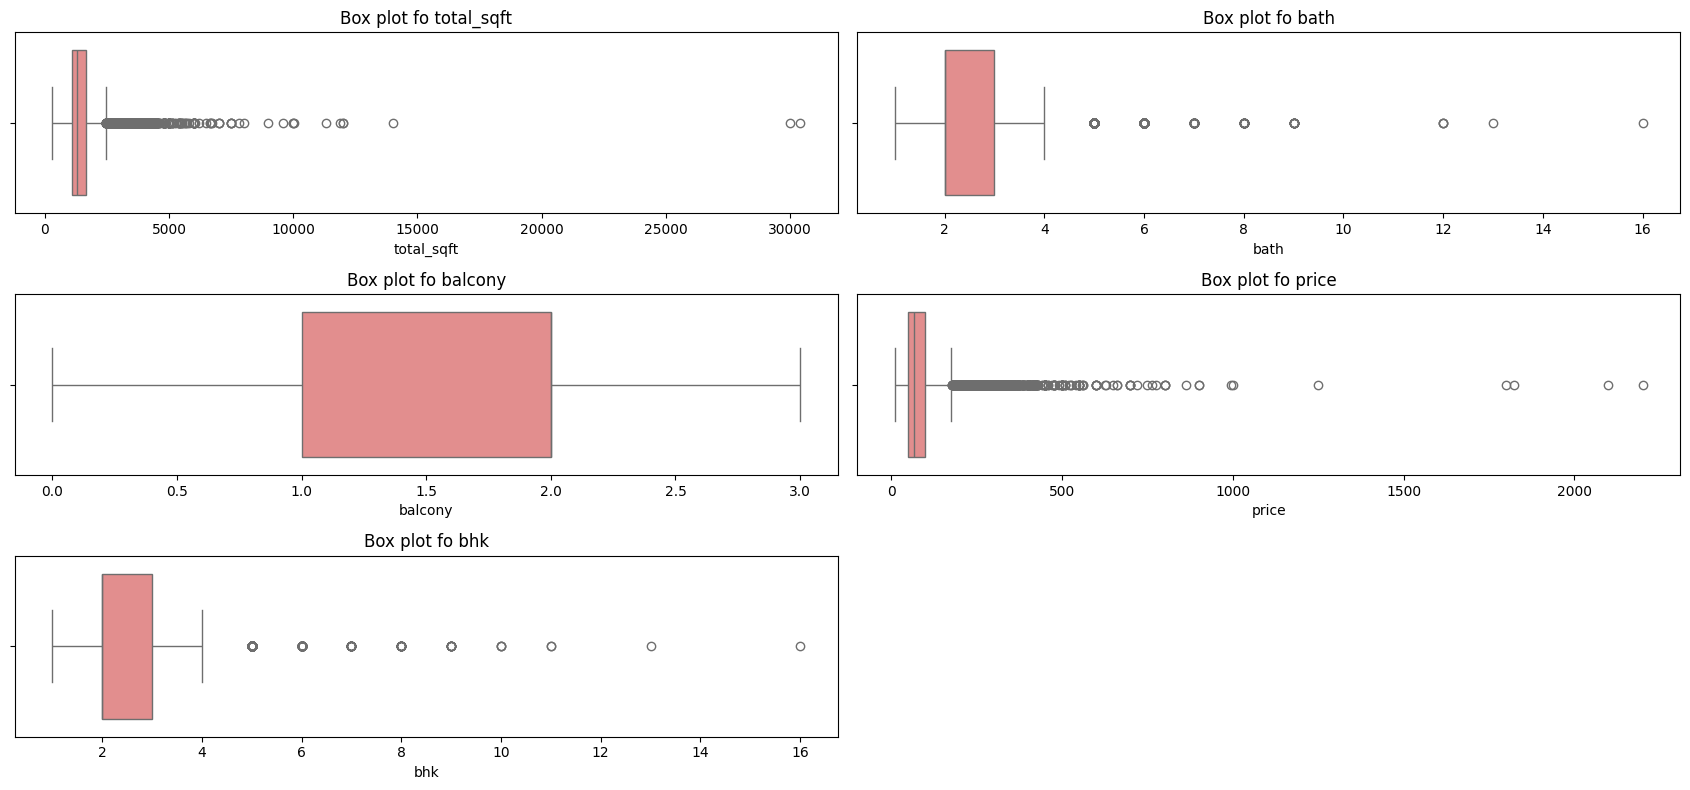

In [38]:
plt.figure(figsize=[17, 8])
for i, col in enumerate(df.columns[2:7]):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Box plot fo {col}')
    plt.xlabel(col)
    plt.tight_layout();

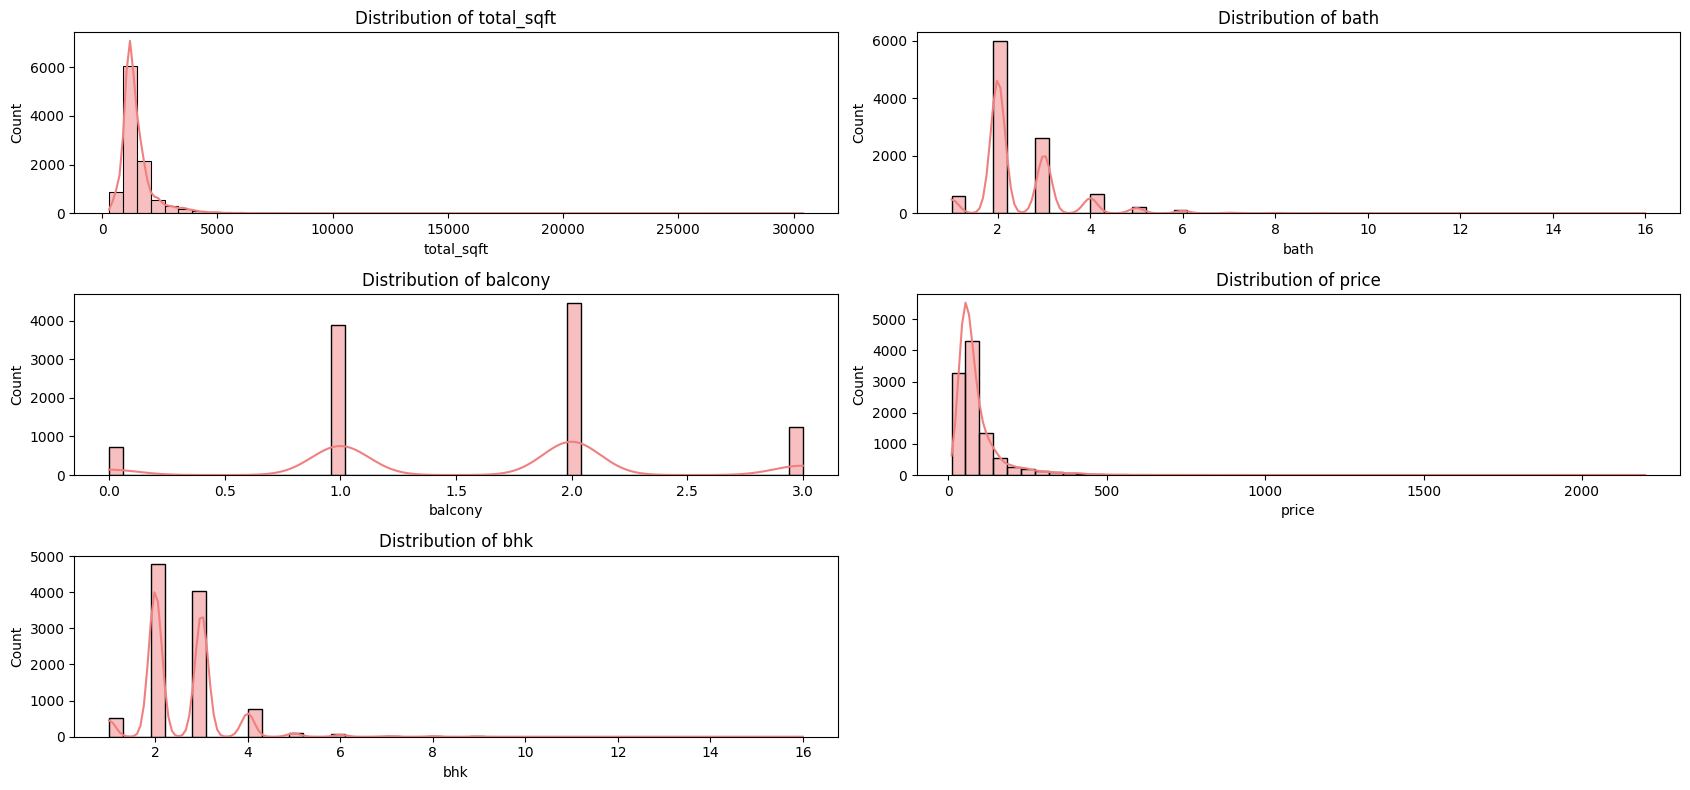

In [39]:
plt.figure(figsize=[17, 8])
for i, col in enumerate(df.columns[2:7]):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=df[col], color='lightcoral', kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.tight_layout();

In [40]:
# remove outliers

df = df[df['bath'] <= 7]
df = df[df['bhk'] <= 7]

df = df[df['total_sqft'] < 15000]
df = df[df['price'] < 1100]

use log transformation

In [41]:
df['total_sqft'] = np.log1p(df['total_sqft'])
df['price'] = np.log1p(df['price'])

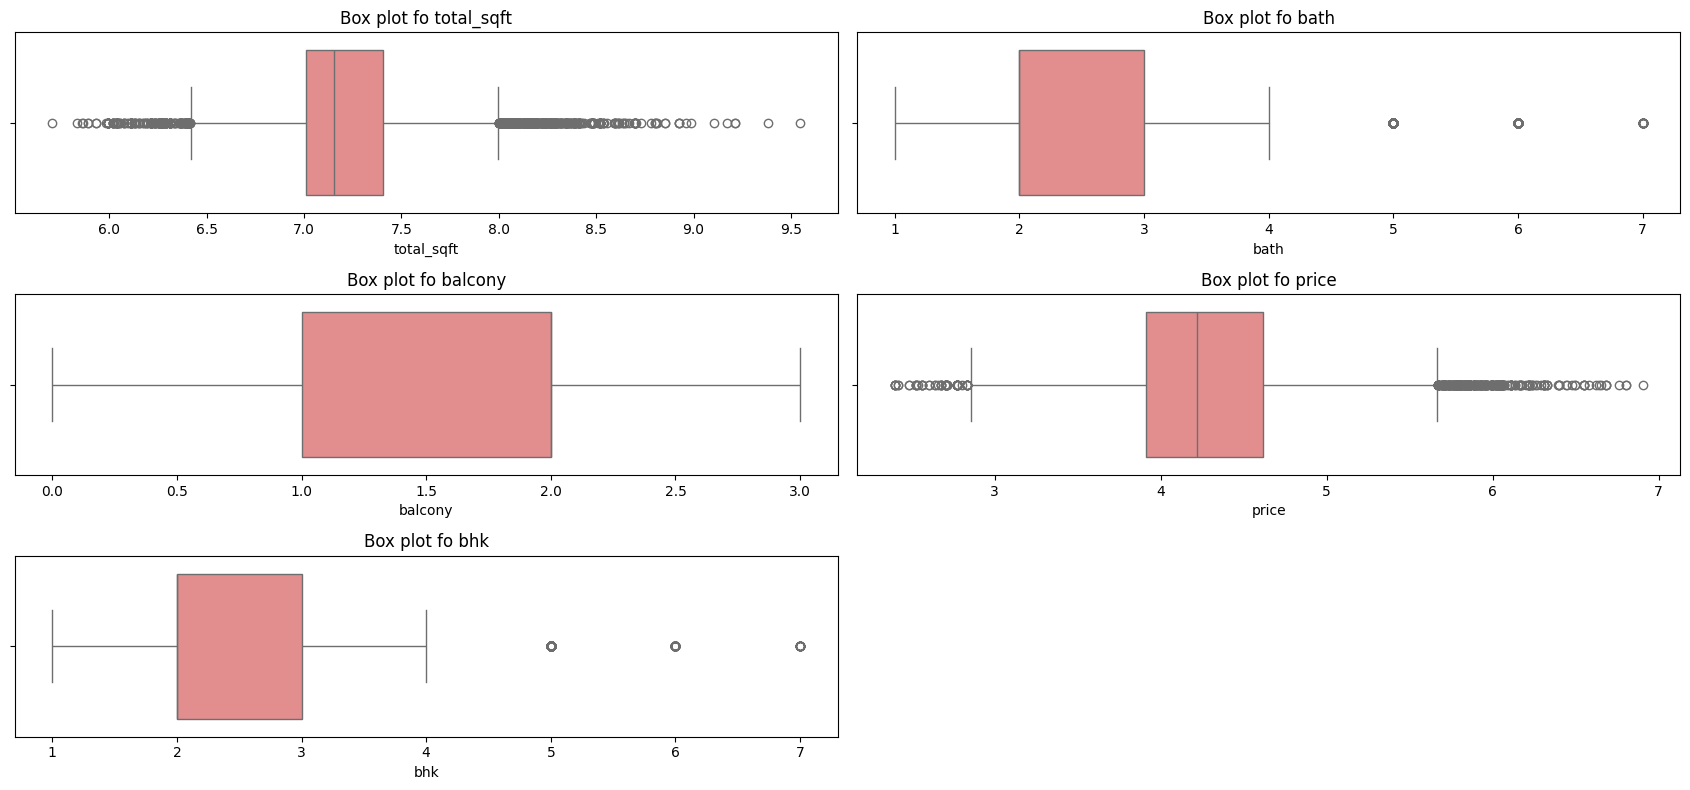

In [42]:
plt.figure(figsize=[17, 8])
for i, col in enumerate(df.columns[2:7]):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Box plot fo {col}')
    plt.xlabel(col)
    plt.tight_layout();

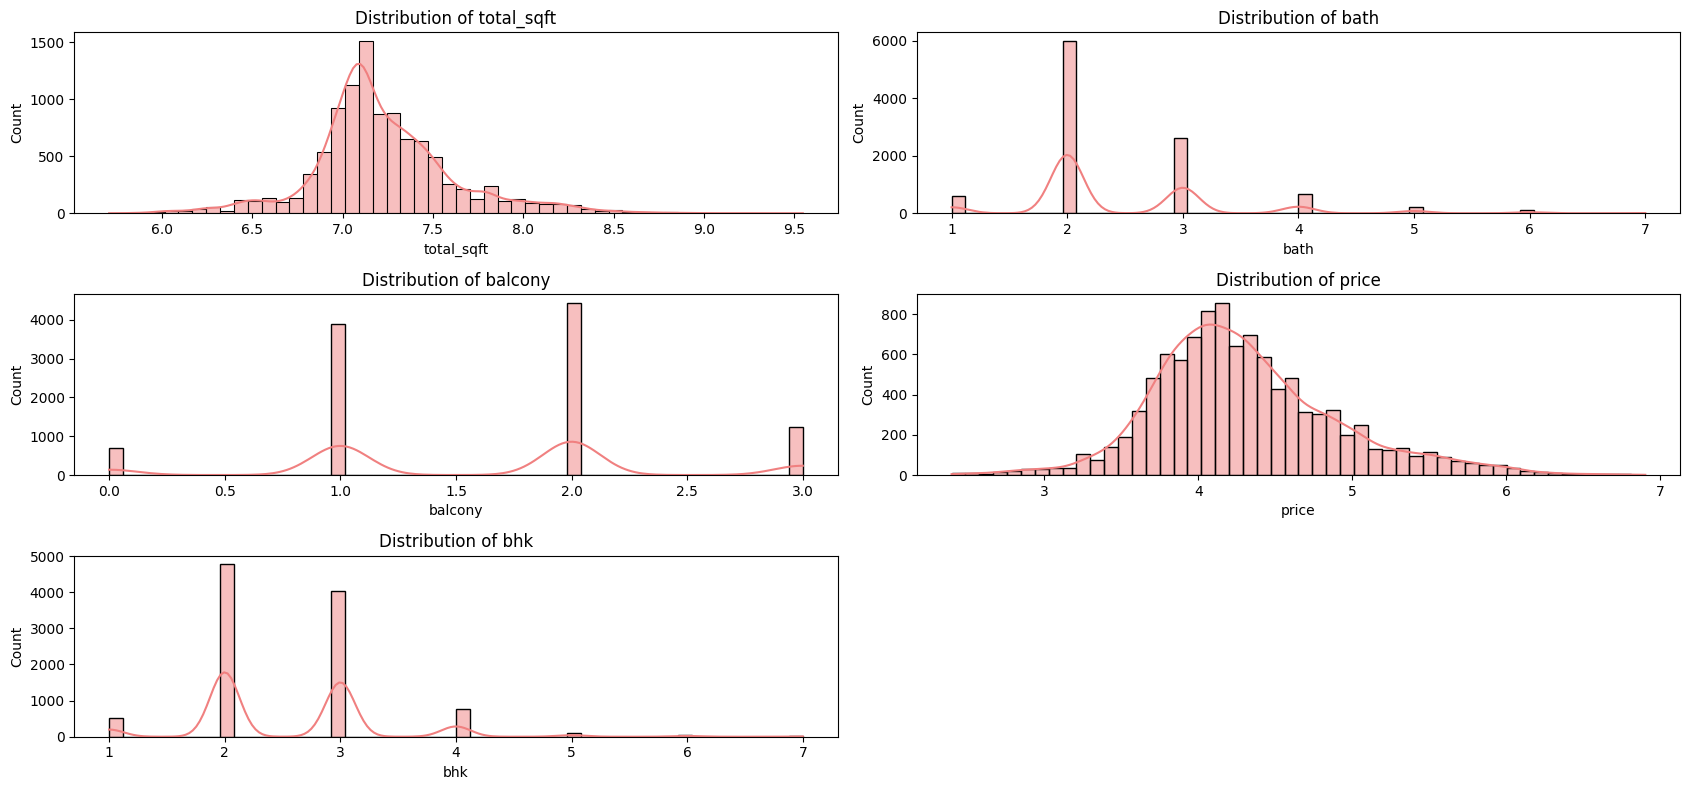

In [43]:
plt.figure(figsize=[17, 8])
for i, col in enumerate(df.columns[2:7]):
    plt.subplot(3, 2, i+1)
    sns.histplot(x=df[col], color='lightcoral', kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.tight_layout();

In [44]:
df.drop(columns=['size', 'price_per_sqft'], axis=1, inplace=True)

In [45]:
x = df.drop(['price'], axis=1)
y = df['price']

In [46]:
x

,location,total_sqft,bath,balcony,bhk
0,1st Block Jayanagar,7.955425,4.0,1.0,4
1,1st Block Jayanagar,7.396949,3.0,2.0,3
2,1st Block Jayanagar,7.536897,2.0,3.0,3
3,1st Block Jayanagar,7.090910,2.0,0.0,3
4,1st Block Jayanagar,7.119636,2.0,2.0,2
...,...,...,...,...,...
10311,other,7.210818,2.0,2.0,2
10312,other,6.700731,1.0,0.0,1
10313,other,7.273093,2.0,2.0,3
10314,other,6.981006,2.0,2.0,2


In [409]:
import joblib

In [37]:
joblib.dump(x, 'x.pkl')

['x.pkl']

In [47]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRFRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error as mse

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [49]:
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [50]:
column_trans = make_column_transformer((
        OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['location']), remainder='passthrough'
)

In [51]:
robust = RobustScaler()
lr = LinearRegression()

In [52]:
pipe = make_pipeline(column_trans, robust, lr)
pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('robustscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [58]:
y_pred_train = pipe.predict(x_train)
y_pred_test = pipe.predict(x_test)

In [59]:
r2_score(y_train, y_pred_train)

0.8451547269850223

In [60]:
r2_score(y_test, y_pred_test)

0.8423354582486167

In [61]:
mse(y_test, y_pred_test)

0.057898293812080025

In [433]:
joblib.dump(pipe, 'pipeline.pkl')

['pipeline.pkl']

In [63]:
train = []
test = []
for i in range(20):
    lr = LinearRegression()
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=i)
    p = make_pipeline(column_trans, lr)
    p.fit(x_train, y_train)
    train.append(r2_score(y_train, p.predict(x_train)))
    test.append(r2_score(y_test, p.predict(x_test)))

In [64]:
train

[0.8449510700669496,
 0.8455892499792317,
 0.8460257214828435,
 0.8444355006609643,
 0.8487640545818673,
 0.8498596834808916,
 0.8438255735446296,
 0.8469925409692226,
 0.8431182573070504,
 0.8475004910647199,
 0.8466092455470298,
 0.8493406329712945,
 0.8452075037910196,
 0.843293989116976,
 0.8517502128877377,
 0.8472519730809904,
 0.847455457435505,
 0.8433668928587857,
 0.8455289048183534,
 0.8473717957624061]

In [65]:
test

[0.8429926226948421,
 0.8399435996117842,
 0.8390308159714273,
 0.8429513606368694,
 0.8332406340482146,
 0.8302678602274911,
 0.8444226832112075,
 0.837071669787606,
 0.8459225559365233,
 0.836826007443504,
 0.8380439003327365,
 0.8320706691400512,
 0.8411919697561538,
 0.8470041816573524,
 0.8238832841496133,
 0.8372372943992876,
 0.8355285715811376,
 0.8454262375187481,
 0.8411432666795853,
 0.836787203058462]

# hyper-parameter training

In [387]:
from sklearn.model_selection import GridSearchCV

In [388]:
param = {
    'n_estimators' : [100, 200, 300],
    'criterion' : ['squared_error', 'absolute_error'],
    'max_depth' : [4, 6, 8],
    'max_leaf_nodes' : [4, 6]
}

In [395]:
grid1 = GridSearchCV(RandomForestRegressor(n_jobs=-1), param_grid=param, scoring='r2')
pipe = make_pipeline(column_trans, grid1)
pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [396]:
b = grid1.best_params_
b

{'criterion': 'squared_error',
 'max_depth': 4,
 'max_leaf_nodes': 6,
 'n_estimators': 300}

In [400]:
def hyper_model_train(clf):
    # fit model
    pipe = make_pipeline(column_trans, clf)
    pipe.fit(x_train, y_train)
    # predict testing
    y_pred_test = pipe.predict(x_test)
    # predict training
    y_pred_train = pipe.predict(x_train)
    print(r2_score(y_train, y_pred_train))
    print(r2_score(y_test,  y_pred_test))

In [401]:
hyper_model_train(RandomForestRegressor(**b))

0.7185764858801829
0.7188161531295036
